In [59]:
from matplotlib import pyplot as plt
import numpy as np
import os
import random

# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, LSTM

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# resample signal to n samples
from scipy.signal import resample

# XML parser
import xml.etree.ElementTree as ET

# encoding and normalizing data
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [3]:
NUM_POINTS = 50

In [60]:
data = []


for root, subdirs, files in os.walk('../xml_logs'):
    if 'ipynb_checkpoint' in root:
        continue
    
    if len(files) > 0:
        for f in tqdm(files):
            if '.xml' in f:
                fname = f.split('.')[0]
                label = fname[:-2]
                
                if label == "question_mark":
                    continue
                
                xml_root = ET.parse(f'{root}/{f}').getroot()
                
                points = []
                for element in xml_root.findall('Point'):
                    x = element.get('X')
                    y = element.get('Y')
                    points.append([x, y])
                    
                points = np.array(points, dtype=float)
                
                scaler = StandardScaler()
                points = scaler.fit_transform(points)
                
                resampled = resample(points, NUM_POINTS)
                
                data.append((label, resampled))

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

...

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

### Load Test Data from own files ###

In [61]:
test_data = []


for root, subdirs, files in os.walk('../datasets'):
    if 'ipynb_checkpoint' in root:
        continue
    
    if len(files) > 0:
        for f in tqdm(files):
            if '.xml' in f:
                fname = f.split('.')[0]
                label = fname[:-2]
                
                xml_root = ET.parse(f'{root}/{f}').getroot()
                
                points = []
                for element in xml_root.findall('Point'):
                    x = element.get('X')
                    y = element.get('Y')
                    points.append([x, y])
                    
                points = np.array(points, dtype=float)
                
                scaler = StandardScaler()
                points = scaler.fit_transform(points)
                
                resampled = resample(points, NUM_POINTS)
                
                test_data.append((label, resampled))

  0%|          | 0/151 [00:00<?, ?it/s]

In [62]:
print(data[0])

('delete_mark', array([[-0.59194871, -2.0564185 ],
       [-1.10749981, -1.72358499],
       [-0.73167789, -1.57949298],
       [-0.78982185, -1.33604894],
       [-0.63813219, -1.19769015],
       [-0.61820291, -0.97538177],
       [-0.44748775, -0.81930244],
       [-0.33869274, -0.63089084],
       [-0.18408279, -0.44177709],
       [-0.04503403, -0.26699279],
       [ 0.13402561, -0.11031941],
       [ 0.31877319,  0.0414887 ],
       [ 0.51111755,  0.15913344],
       [ 0.69051573,  0.26020367],
       [ 0.8638507 ,  0.36411051],
       [ 1.04083879,  0.43493292],
       [ 1.23708325,  0.61934448],
       [ 1.41892455,  0.73421804],
       [ 1.59796671,  0.81434867],
       [ 1.83782307,  0.90144771],
       [ 1.82299607,  0.96430651],
       [ 1.58686263,  0.99273416],
       [ 1.40841071,  0.99361867],
       [ 1.19702547,  1.0171165 ],
       [ 0.99961903,  1.02758324],
       [ 0.77968464,  1.03353725],
       [ 0.43026292,  1.07362357],
       [ 0.06962748,  1.12189154],
    

In [63]:
print(test_data[0])

('left_curly_brace_', array([[ 2.53118600e+00,  1.51479550e-01],
       [ 1.78023252e+00, -1.74033308e+00],
       [ 1.69174688e+00, -1.28349697e+00],
       [ 1.39470240e+00, -1.55763993e+00],
       [ 1.28484314e+00, -1.35215240e+00],
       [ 1.06722534e+00, -1.46412362e+00],
       [ 9.14362000e-01, -1.28797077e+00],
       [ 6.85684829e-01, -1.28403509e+00],
       [ 5.73415908e-01, -1.09659104e+00],
       [ 4.10200123e-01, -1.03477255e+00],
       [ 3.59013797e-01, -8.58236015e-01],
       [ 2.55583957e-01, -7.53017042e-01],
       [ 2.85841556e-01, -5.97523916e-01],
       [ 3.39458925e-01, -5.48053081e-01],
       [ 4.74216404e-01, -4.29960083e-01],
       [ 5.73191543e-01, -3.78060512e-01],
       [ 6.27653202e-01, -2.91842639e-01],
       [ 6.21310158e-01, -2.44520498e-01],
       [ 6.18950341e-01, -1.76694072e-01],
       [ 5.25430809e-01, -1.37488593e-01],
       [ 4.00673406e-01, -8.36829636e-02],
       [ 2.16260671e-01, -5.09145070e-02],
       [ 3.73689133e-02, -2.5357

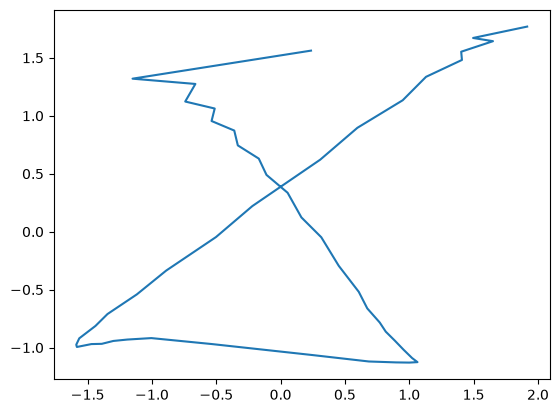

In [67]:
sample_data = random.sample(test_data, 1)[0]

label = sample_data[0]
sequence = sample_data[1]

plt.plot(sequence.T[0], sequence.T[1]*-1)

## Prepare Data ##

Train und Validation Data


In [68]:
# Prepare the data
labels = [sample[0] for sample in data]
print("labels: ", set(labels))

# encode (make string-labels numerical)
encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(labels)
print("encoded: ", set(labels_encoded))

# get labels of data
y = to_categorical(labels_encoded)
print("num labels (encoded): ", len(y[0]))

# get point sequences of data
sequences = [sample[1] for sample in data]
X = np.array(sequences)

# split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=labels_encoded)
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

labels:  {'check', 'delete_mark', 'rectangle', 'triangle', 'left_curly_brace', 'x', 'v', 'caret', 'star', 'arrow', 'left_sq_bracket', 'right_curly_brace', 'right_sq_bracket', 'pigtail', 'circle'}
encoded:  {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)}
num labels (encoded):  15
(3960, 50, 2) (990, 50, 2) (3960, 15) (990, 15)


Test Data

In [69]:

test_labels = [sample[0] for sample in test_data]
test_sequences = [sample[1] for sample in test_data]

X_test = np.array(test_sequences)

test_labels = [label.rstrip("_") for label in test_labels]
test_labels_encoded = encoder.transform(test_labels)
y_test = to_categorical(test_labels_encoded, num_classes=len(encoder.classes_))

print(X_test.shape, y_test.shape)

(150, 50, 2) (150, 15)


## Define Model ##

In [22]:
configs = [
    {"name": "LSTM-64", "lstm_units": 64},
    {"name": "LSTM-32", "lstm_units": 32},
    {"name": "LSTM-16", "lstm_units": 16},
    {"name": "LSTM-8",  "lstm_units": 8},
]

In [23]:
def create_model(units):
    model = Sequential()
    model.add(Input(shape=(NUM_POINTS, 2)))
    model.add(LSTM(units=units))
    model.add(Dense(len(set(labels)), activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    return model

In [122]:
from sklearn.metrics import accuracy_score
import time as time
results = []
for config in configs:
    print(f"Training model: {config['name']} with {config['lstm_units']} LSTM units")
    
    model = create_model(config['lstm_units'])
    
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    stop_early = EarlyStopping(monitor='val_loss', patience=3)
    
    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=1,
        callbacks=[reduce_lr, stop_early]
    )
    
    start_time = time.time()
    predictions = model.predict(X_test)
    prediction_time = time.time() - start_time
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(y_test, axis=1)
    
    acc = accuracy_score(true_labels, predicted_labels)
    conf_matrix = confusion_matrix(true_labels, predicted_labels)
    
    results.append({
        "config": config['name'],
        "num_units": config['lstm_units'],
        "num_params": model.count_params(),
        "accuracy": acc,
        "confusion_matrix": conf_matrix,
        "model": model,
        "history": history,
        "prediction_time": prediction_time
    })


Training model: LSTM-64 with 64 LSTM units
Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6126 - loss: 1.4653 - val_accuracy: 0.9212 - val_loss: 0.5109 - learning_rate: 0.0010
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9283 - loss: 0.3014 - val_accuracy: 0.9616 - val_loss: 0.1714 - learning_rate: 0.0010
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9753 - loss: 0.1224 - val_accuracy: 0.9848 - val_loss: 0.0876 - learning_rate: 0.0010
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9838 - loss: 0.0767 - val_accuracy: 0.9909 - val_loss: 0.0524 - learning_rate: 0.0010
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9831 - loss: 0.0701 - val_accuracy: 0.9909 - val_loss: 0.0475 - learning_rate: 0.0010
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9813 - loss: 0.0697 - val_accuracy: 0.9899 - val_loss: 0.0454 - learning_rate: 0.0010
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5m

## Now 1$ Recognizer ##

In [123]:
import sys

sys.path.append("../task_1")

from recognizer import DollarRecognizer, Point

In [124]:
dollar_rec = DollarRecognizer()

for root, subdirs, files in os.walk("../xml_logs"):
        for f in tqdm(files):
            if '.xml' in f:
                fname = f.split('.')[0]
                label = fname[:-2]
                
                if label == "question_mark":
                    continue

                xml_root = ET.parse(f'{root}/{f}').getroot()

                points = []
                for element in xml_root.findall('Point'):
                    x = element.get('X')
                    y = element.get('Y')
                    points.append(Point(float(x), float(y)))

                dollar_rec.addGesture(label, points)


0it [00:00, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

...

  0%|          | 0/160 [00:00<?, ?it/s]

0it [00:00, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

In [125]:
true_labels = []
predicted_labels = []

start_time = time.time()
for label, points in test_data:
    result = dollar_rec.recognize([Point(float(p[0]), float(p[1])) for p in points], useProtractor=True)
    
    true_labels.append(label.rstrip("_"))
    predicted_labels.append(result.name)

prediction_time = time.time() - start_time
acc = accuracy_score(true_labels, predicted_labels)
conf_matrix = confusion_matrix(true_labels, predicted_labels)


print("Accuracy:", acc)
print("Prediction time:", prediction_time)
print("Time per sample:", prediction_time / len(test_data))

Accuracy: 0.6933333333333334
Prediction time: 3.0752298831939697
Time per sample: 0.020501532554626466


## Analysis ##

* Trained all LSTM models on the Wobbrock unistroke gesture dataset.
* Applied a stratified 80/20 train-validation split.
* Evaluated the final models on the separate test dataset consisting of 150 self-recorded gesture samples.
* Compared four LSTM configurations with 8, 16, 32, and 64 
* Trained $1 Gesture Recognizer using the complete wobrock data and test on the same self-recorded gestures 

* The Website listed "zig zag" as one of the 16 gestures, this was not included in the xml logs
* Instead Question Mark was in the files 
* Question Mark has been left out 
* Trained, validated and tested on the other 15 remaining gestures

In [126]:
results.append({
    "config": "$1 Recognizer",
    "num_units": "-",
    "num_params": 0,
    "accuracy": acc,
    "prediction_time": prediction_time,
    "confusion_matrix": conf_matrix

})

In [127]:
#supported by ChatGPT
import pandas as pd

summary = pd.DataFrame([
    {
        "Model": r["config"],
        "LSTM Units": r["num_units"],
        "Parameters": r["num_params"],
        "Accuracy (%)": round(r["accuracy"] * 100, 2),
        "Validation Accuracy (%)": (
            round(max(r["history"].history["val_accuracy"]) * 100, 2)
            if "history" in r
            else "-"
        ),
        "Prediction Time (ms)": round(r["prediction_time"] * 1000, 2),
        "Prediction Time per Sample (ms)": round(r["prediction_time"] * 1000 / len(test_data), 2)
    }
    for r in results
])

summary.sort_values("Parameters")

,Model,LSTM Units,Parameters,Accuracy (%),Validation Accuracy (%),Prediction Time (ms),Prediction Time per Sample (ms)
4,$1 Recognizer,-,0,69.33,-,3075.23,20.50
3,LSTM-8,8,487,86.00,97.27,124.10,0.83
2,LSTM-16,16,1471,84.00,99.09,125.34,0.84
1,LSTM-32,32,4975,86.00,99.19,130.45,0.87
0,LSTM-64,64,18127,81.33,99.29,126.50,0.84


In [58]:
print(set(true_labels))

print(set(predicted_labels))

{'check', 'delete_mark', 'rectangle', 'triangle', 'left_curly_brace', 'x', 'v', 'caret', 'arrow', 'star', 'left_sq_bracket', 'right_curly_brace', 'right_sq_bracket', 'pigtail', 'circle'}
{'left_sq_bracket', 'check', 'delete_mark', 'rectangle', 'triangle', 'left_curly_brace', 'x', 'pigtail', 'v', 'arrow', 'star', 'question_mark', 'right_curly_brace', 'right_sq_bracket', 'caret', 'circle'}


* The LSTM models achieved higher test accuracy than the $1 Recognizer on the custom gesture dataset.
* The best test accuracy was reached by LSTM-8 and LSTM-32, both achieving 86.0%.
* Increasing the number of LSTM units did not lead to better performance. The largest model (LSTM-64) achieved the lowest test accuracy (81.33%) 
* All LSTM models achieved very high validation accuracies between 97% and 99% on the Wobbrock dataset. However, the lower test accuracies on the custom dataset suggest a significant difference  between the training data and the self-recorded gestures.
* The prediction times of the LSTM models were very similar, ranging from 0.83 ms to 0.87 ms per sample. Therefore, reducing the parameter count had only a small impact on inference speed.
* The $1 Recognizer achieved a lower accuracy (69.33%) and required substantially more time (20.50 ms per sample) than all LSTM models.
* Considering accuracy, parameter count, and prediction speed together, LSTM-8 appears to provide the best trade-off. It achieved one of the highest accuracies while using only 487 parameters, making it significantly smaller than the other LSTM models.

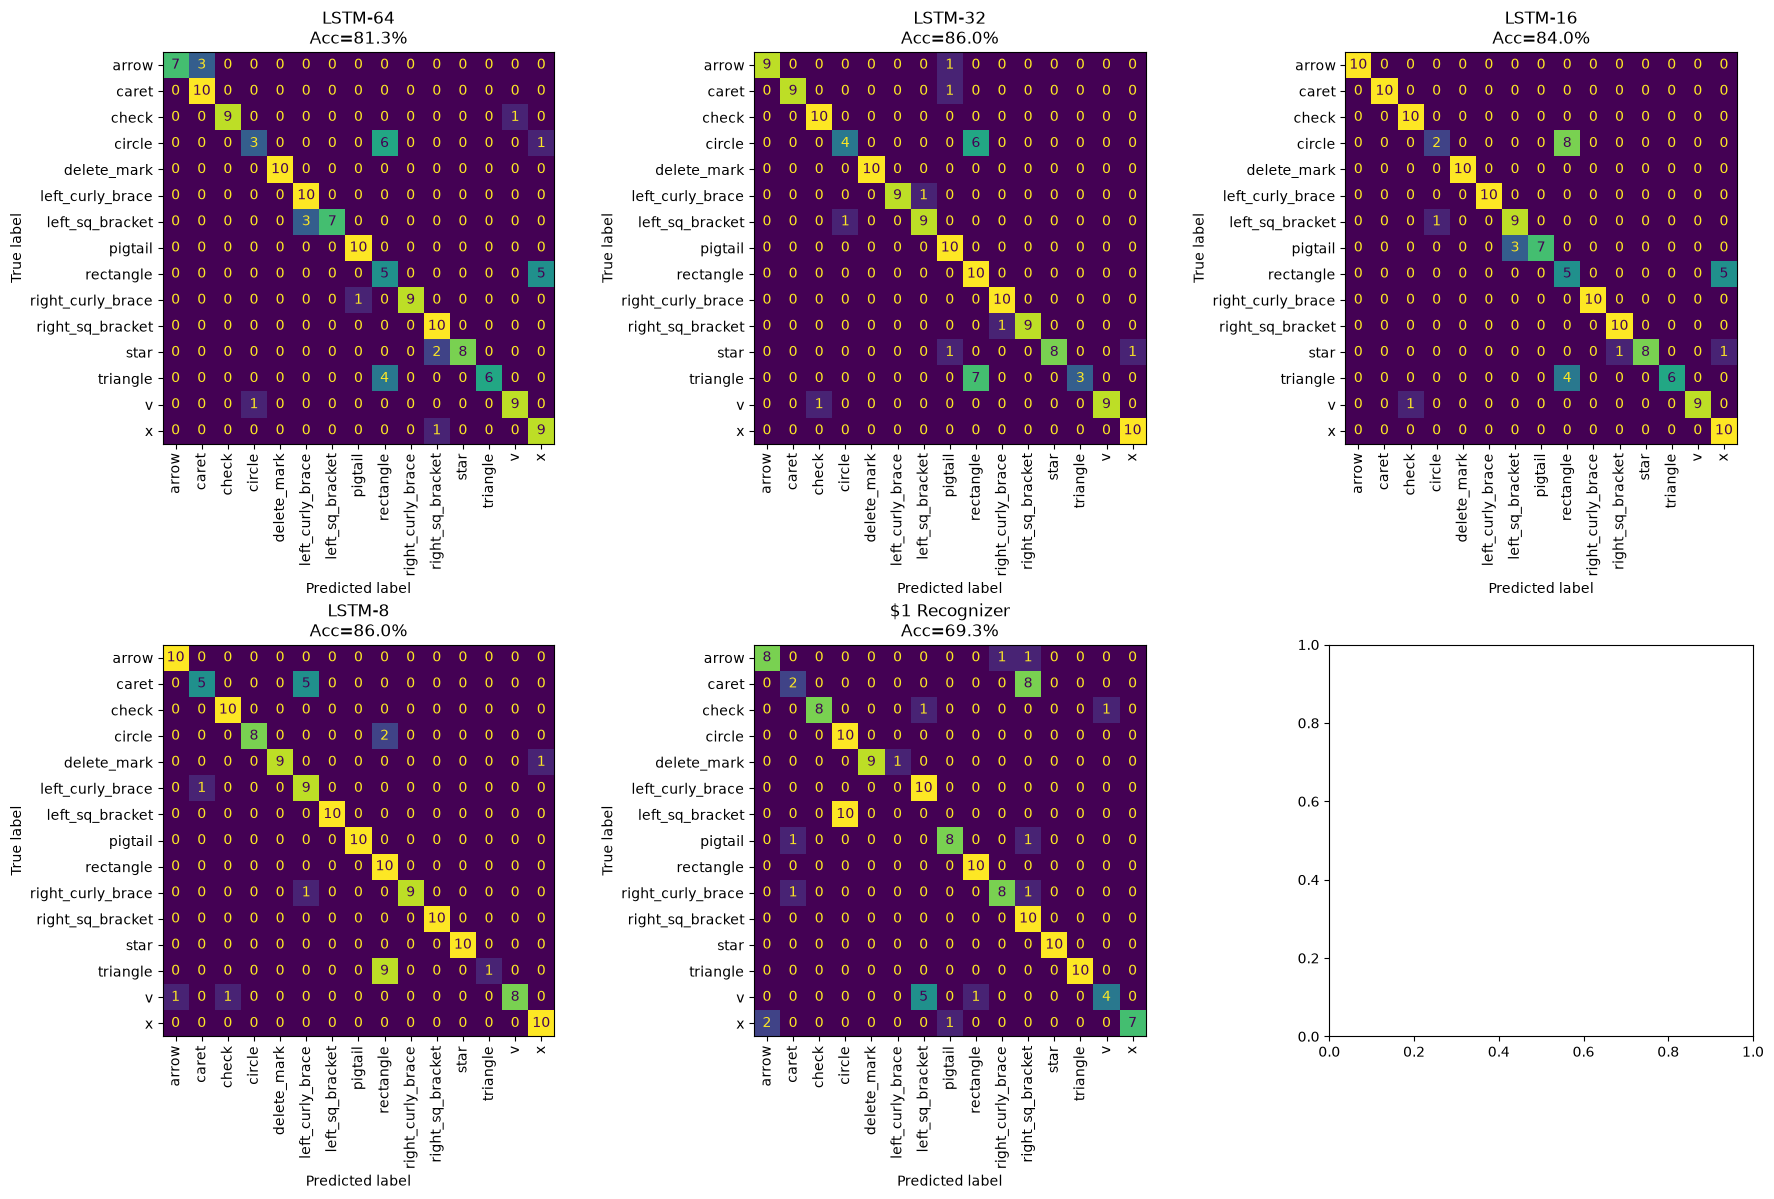

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, r in zip(axes, results):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=r["confusion_matrix"],
        display_labels=encoder.classes_
    )

    disp.plot(
        ax=ax,
        colorbar=False,
        xticks_rotation=90
    )

    ax.set_title(
        f'{r["config"]}\nAcc={r["accuracy"]*100:.1f}%'
    )

plt.tight_layout()
plt.show()

    
* Interestingly, all LSTM models show a very similar error pattern. The largest source of confusion is the distinction between circle, rectangle, and triangle. In many cases, circles and triangles are incorrectly classified as rectangles.
* The $1 Recognizer shows a very different behavior. For rectangle, triangle, and circle, it achieves perfect classification and correctly recognizes all ten test samples of each class.
* However it performs much worse on other gesture classes. Left_sq_bracket and left_curly_brace are complete failures, as none of the corresponding test gestures are classified correctly. The caret gesture also shows a significant lower recognition rate.
* As a result, the lower overall accuracy of the $1 Recognizer is mainly caused by a few gesture classes with very poor performance, whereas the LSTM models achieve a more balanced performance across most classes.
* Comparing LSTM-8 and LSTM-32, which both achieve an overall accuracy of 86%, reveals an trade-off. The LSTM-32 recognizes only 4 out of 10 circles correctly but correctly classifies 3 triangles. In contrast, the LSTM-8 correctly recognizes 8 circles, but only 1 triangle. Although both models reach the same overall accuracy, they make different types of classification errors.

* Overall, I would choose LSTM-8 for a practical application.
* It achieved the highest test accuracy (86%) while using the fewest parameters (487).
* Its prediction time was also among the fastest of all tested models.
* Larger LSTM models did not improve the results, despite having significantly more parameters.
* Compared to the $1 Recognizer, LSTM-8 achieved higher accuracy and more consistent performance across the different gesture classes.
* Therefore, LSTM-8 provides the best trade-off between accuracy, speed, and model complexity.